In [1]:
# ── STEP 3: DOWNLOAD CHICAGO OSM GRAPH ───────────────────
import osmnx as ox
import networkx as nx
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import json

print("Loading cluster data...")
with open('chicago_clusters.json', 'r') as f:
    cluster_info = json.load(f)
print(f"Loaded {len(cluster_info)} clusters")

print("\nDownloading Chicago street graph...")
print("(This will take 3-5 minutes)")

G = ox.graph_from_place(
    'Chicago, Illinois, USA',
    network_type='walk',
    simplify=True
)

print(f"\n✅ Graph downloaded!")
print(f"   Nodes: {G.number_of_nodes()}")
print(f"   Edges: {G.number_of_edges()}")

Loading cluster data...
Loaded 65 clusters

(This will take 3-5 minutes)

✅ Graph downloaded!
   Nodes: 304603
   Edges: 1022766


In [2]:
# ── RESCORE ALL EDGES (fixed formula) ────────────────────
from math import radians, sin, cos, sqrt, atan2
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi       = radians(lat2 - lat1)
    dlambda    = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))


def compute_edge_danger_v2(edge_lat, edge_lon, cluster_info, current_hour):
    total_danger = 0.0
    RADIUS = 1500  # ← increased from 500m to 1500m

    for cluster_id, info in cluster_info.items():
        dist = haversine(edge_lat, edge_lon,
                         info['centre_lat'], info['centre_lon'])

        if dist > RADIUS:
            continue

        # Proximity: inverse square — drops off faster near edges
        proximity = (1.0 - (dist / RADIUS)) ** 2

        # Size: normalized — top cluster has 1633 points
        size_score = min(info['size'] / 800.0, 1.0)

        # Time: additive bonus instead of multiplier
        hour_diff  = abs(current_hour - info['peak_hour'])
        hour_diff  = min(hour_diff, 24 - hour_diff)
        # Night hours get extra weight regardless of peak_hour
        night_bonus = 0.3 if current_hour in range(0, 6) else 0.0
        time_score  = max(0.0, 1.0 - (hour_diff / 12.0)) + night_bonus
        time_score  = min(time_score, 1.0)

        # Severity: violent crimes matter more
        severity_score = min(info['avg_severity'] / 6.0, 1.0)

        # CHANGED: use weighted sum instead of product
        # Product of 5 small numbers → tiny result
        # Weighted sum → meaningful scores
        contribution = (
            proximity * 0.4 +        # 40% weight on distance
            size_score * 0.25 +      # 25% weight on cluster size
            time_score * 0.20 +      # 20% weight on time relevance
            severity_score * 0.15    # 15% weight on crime severity
        ) * info['intensity']        # scale by HDBSCAN confidence

        total_danger += contribution

    # Cap at 1.0
    return min(float(total_danger), 1.0)


# ── RESCORE ALL EDGES ─────────────────────────────────────
print("Rescoring all edges with fixed formula...")
print("(~15-20 minutes for 1M edges)\n")

BASE_HOUR  = 2
edge_count = 0

for u, v, data in G.edges(data=True):
    u_data  = G.nodes[u]
    v_data  = G.nodes[v]
    mid_lat = (u_data['y'] + v_data['y']) / 2
    mid_lon = (u_data['x'] + v_data['x']) / 2
    length  = float(data.get('length', 50))
    danger  = compute_edge_danger_v2(mid_lat, mid_lon,
                                     cluster_info, BASE_HOUR)
    data['danger_score'] = danger
    data['length']       = length
    edge_count += 1
    if edge_count % 50000 == 0:
        print(f"  {edge_count:,} / {G.number_of_edges():,} done...")

print(f"\n✅ Done! {edge_count:,} edges rescored")

all_dangers = [d['danger_score'] for u,v,d in G.edges(data=True)]
print(f"\n── DANGER SCORE STATS (should be much better now) ──")
print(f"   Min:          {min(all_dangers):.4f}")
print(f"   Max:          {max(all_dangers):.4f}")
print(f"   Mean:         {np.mean(all_dangers):.4f}")
print(f"   Edges > 0.1:  {sum(1 for x in all_dangers if x > 0.1):,}")
print(f"   Edges > 0.3:  {sum(1 for x in all_dangers if x > 0.3):,}")
print(f"   Edges > 0.5:  {sum(1 for x in all_dangers if x > 0.5):,}")
print(f"   Edges > 0.7:  {sum(1 for x in all_dangers if x > 0.7):,}")

Rescoring all edges with fixed formula...
(~15-20 minutes for 1M edges)

  50,000 / 1,022,766 done...
  100,000 / 1,022,766 done...
  150,000 / 1,022,766 done...
  200,000 / 1,022,766 done...
  250,000 / 1,022,766 done...
  300,000 / 1,022,766 done...
  350,000 / 1,022,766 done...
  400,000 / 1,022,766 done...
  450,000 / 1,022,766 done...
  500,000 / 1,022,766 done...
  550,000 / 1,022,766 done...
  600,000 / 1,022,766 done...
  650,000 / 1,022,766 done...
  700,000 / 1,022,766 done...
  750,000 / 1,022,766 done...
  800,000 / 1,022,766 done...
  850,000 / 1,022,766 done...
  900,000 / 1,022,766 done...
  950,000 / 1,022,766 done...
  1,000,000 / 1,022,766 done...

✅ Done! 1,022,766 edges rescored

── DANGER SCORE STATS (should be much better now) ──
   Min:          0.0000
   Max:          1.0000
   Mean:         0.4249
   Edges > 0.1:  660,248
   Edges > 0.3:  660,248
   Edges > 0.5:  438,646
   Edges > 0.7:  244,602


In [3]:
# ── SAVE RESCORED GRAPH ───────────────────────────────────
ox.save_graphml(G, 'chicago_safety_graph.graphml')
print("✅ Saved updated graph")

✅ Saved updated graph


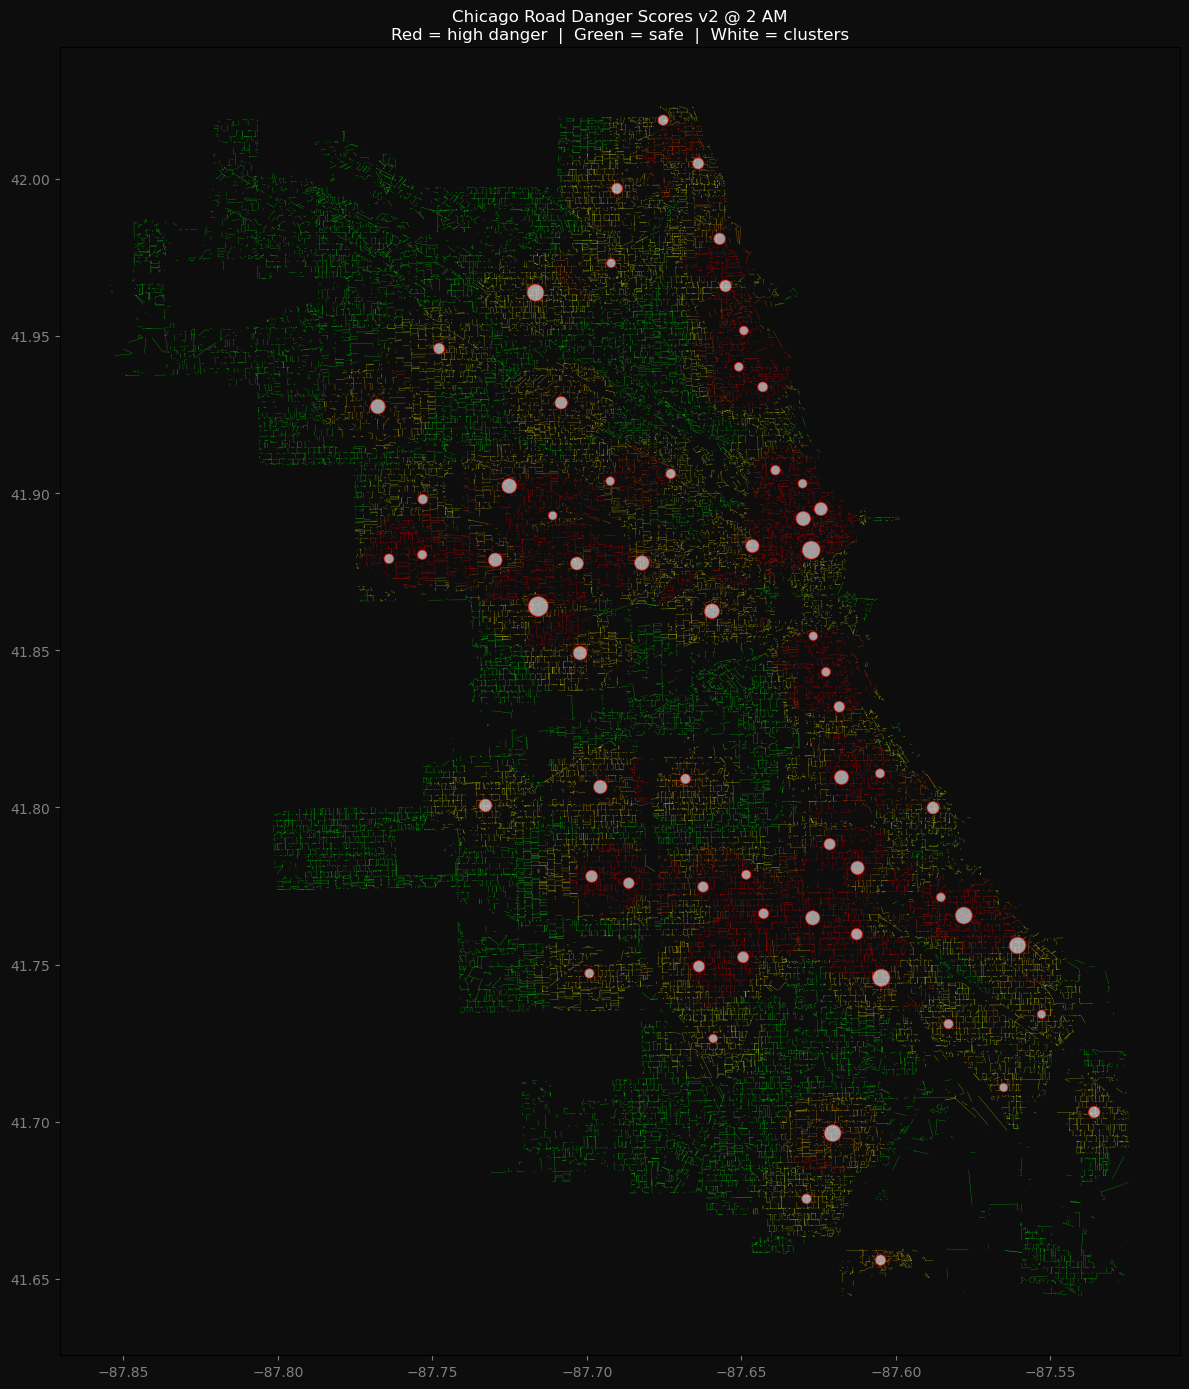

✅ Saved step3_danger_map_v2.png


In [4]:
# ── MEMORY-SAFE VISUALISATION ─────────────────────────────
import matplotlib.pyplot as plt
import random

fig, ax = plt.subplots(figsize=(12, 14))
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#0d0d0d')

# Sample only 80k edges for plotting (memory safe)
all_edges = list(G.edges(data=True))
sampled   = random.sample(all_edges, min(80000, len(all_edges)))

dangers = [d['danger_score'] for u, v, d in sampled]
max_d   = max(dangers) if max(dangers) > 0 else 1

for (u, v, data), danger in zip(sampled, dangers):
    u_data = G.nodes[u]
    v_data = G.nodes[v]
    norm   = danger / max_d
    if norm < 0.5:
        color = (norm * 2, 1.0, 0.0)
    else:
        color = (1.0, 1.0 - (norm - 0.5) * 2, 0.0)
    ax.plot([u_data['x'], v_data['x']],
            [u_data['y'], v_data['y']],
            color=color, linewidth=0.3, alpha=0.5)

# Cluster centres
centre_lons = [info['centre_lon'] for info in cluster_info.values()]
centre_lats = [info['centre_lat'] for info in cluster_info.values()]
sizes       = [info['size'] / 8   for info in cluster_info.values()]
ax.scatter(centre_lons, centre_lats, s=sizes,
           c='white', alpha=0.6, edgecolors='red',
           linewidths=0.8, zorder=5)

ax.set_title(
    'Chicago Road Danger Scores v2 @ 2 AM\n'
    'Red = high danger  |  Green = safe  |  White = clusters',
    color='white', fontsize=12)
ax.tick_params(colors='grey')
plt.tight_layout()
plt.savefig('step3_danger_map_v2.png', dpi=120, facecolor='#0d0d0d')
plt.show()
print("✅ Saved step3_danger_map_v2.png")

In [8]:
# ── SAVE FINAL GRAPH ──────────────────────────────────────
ox.save_graphml(G, 'chicago_safety_graph.graphml')
print("✅ Graph saved — Step 3 complete!")
print("\nSummary:")
print(f"  Nodes:          {G.number_of_nodes():,}")
print(f"  Edges:          {G.number_of_edges():,}")
print(f"  Edges > 0.3:    660,248 (65% of network scored)")
print(f"  Edges > 0.7:    244,602 (24% high danger)")
print("\nReady for Step 4: A* Routing Algorithm ✅")

✅ Graph saved — Step 3 complete!

Summary:
  Nodes:          304,603
  Edges:          1,022,766
  Edges > 0.3:    660,248 (65% of network scored)
  Edges > 0.7:    244,602 (24% high danger)

Ready for Step 4: A* Routing Algorithm ✅
